In [38]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

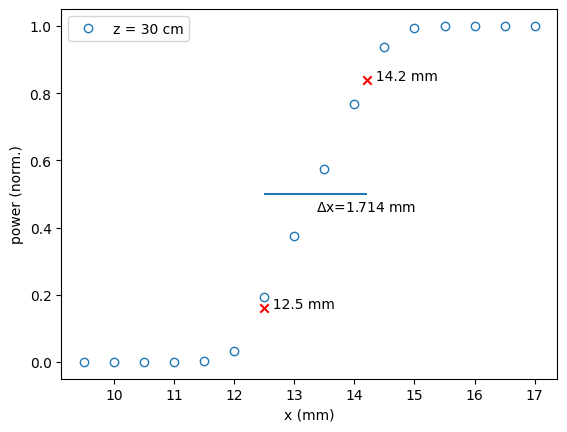

In [104]:
data = np.loadtxt("650nm_laser_spot_size_data.csv", skiprows=1, delimiter=',')
z = np.arange(10,100,20)
x, p = data[:,0], data[:,1:]
#normalize power values
p_mins = np.transpose(np.array([np.min(p[:,col_idx]) * np.ones(len(p[:,0])) for col_idx in range(len(p[0,:]))]))
p_maxs = np.transpose(np.array([np.max(p[:,col_idx]) * np.ones(len(p[:,0])) for col_idx in range(len(p[0,:]))]))
p_norm = (p - p_mins)/(p_maxs - p_mins)
i = 1
#for i in range(len(z)):
percent_lim = 0.12
#x_lin = np.flip(x[(p_norm[:,i]>=percent_lim) & (p_norm[:,i]<=(1 - percent_lim))])
#p_lin = np.flip(p_norm[(p_norm[:,i]>=percent_lim) & (p_norm[:,i]<=(1 - percent_lim)), i])
#x_new = x - np.interp(0.5, p_lin, x_lin)
p_low = np.flip(p_norm[(p_norm[:,i]>=(0.16 - percent_lim)) & (p_norm[:,i]<=(0.16 + percent_lim)), i])
x_low = np.flip(x[(p_norm[:,i]>=(0.16 - percent_lim)) & (p_norm[:,i]<=(0.16 + percent_lim))])
w_low = np.interp(0.16, p_low, x_low)
plt.scatter(w_low, 0.16, c = 'r', marker = 'x')
plt.text(w_low, 0.16, f'  {w_low:0.1f} mm')

p_hi = np.flip(p_norm[(p_norm[:,i]>=(0.84 - percent_lim)) & (p_norm[:,i]<=(0.84 + percent_lim)), i])
x_hi = np.flip(x[(p_norm[:,i]>=(0.84 - percent_lim)) & (p_norm[:,i]<=(0.84 + percent_lim))])
w_hi = np.interp(0.84, p_hi, x_hi)
plt.scatter(w_hi, 0.84, c = 'r', marker = 'x')
plt.text(w_hi, 0.84, f'  {w_hi:0.1f} mm')

plt.hlines(0.5, w_low, w_hi)
plt.text((w_low+w_hi)/2, 0.45, f'$\\Delta$x={np.abs(w_hi-w_low):0.3f} mm')

plt.plot(x, p_norm[:,i],'o' ,mfc='none' ,label=f"z = {z[i]} cm")
plt.xlabel('x (mm)');plt.ylabel('power (norm.)'); plt.legend(); plt.show()

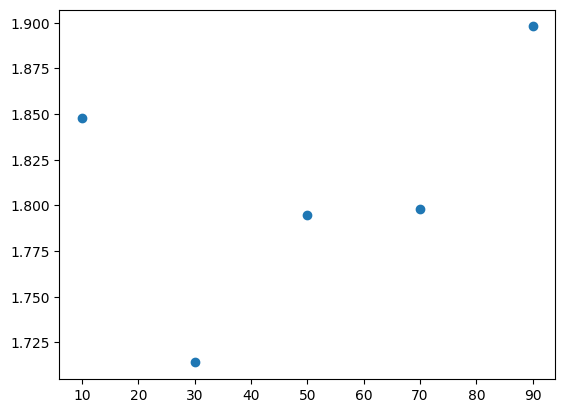

In [101]:
w = np.array([1.848,1.714,1.795,1.798,1.898])

plt.scatter(z, w)

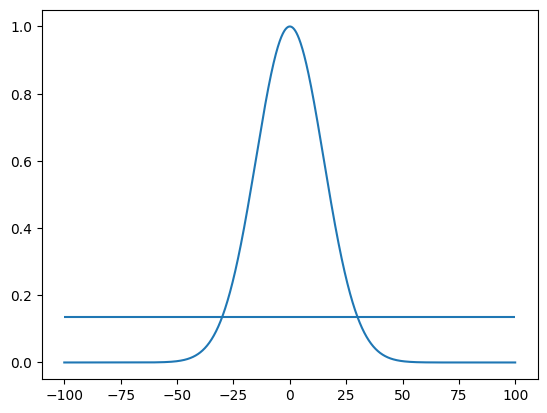

In [67]:
dx,dy = 0.1, 0.1
w0x, w0y = 30, 30
rng = 100
x, y = np.arange(-rng,rng,dx), np.arange(-rng,rng,dy)
Ex, Ey = np.exp(-x**2/w0x**2), np.exp(-y**2/w0y**2)
Ix, Iy = Ex**2, Ey**2
plt.plot(x,Ix)
plt.hlines(1/np.e**2, np.min(x), np.max(x))

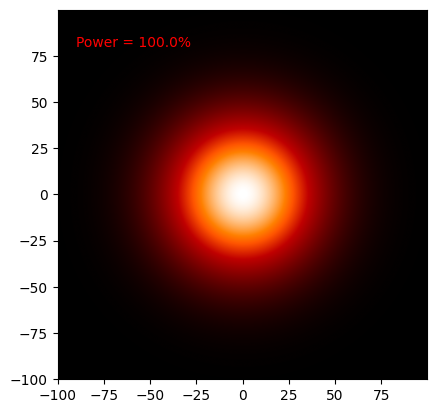

In [68]:
X,Y = np.meshgrid(x,y)
I = np.exp(-2*X**2/4/w0x**2) * np.exp(-2*Y**2/4/w0y**2)
Ptot = np.trapezoid(np.trapezoid(I, axis=1), axis=0) * dx * dy
plt.imshow(I, extent=[X.min(), X.max(), Y.min(), Y.max()],cmap='gist_heat', origin='lower', aspect='equal')
plt.text(-90, 80, f'Power = {Ptot*100/Ptot:.1f}%', color = 'r')
plt.show()

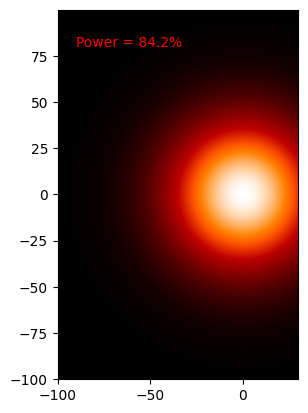

In [69]:
x_lim = 30
X,Y = np.meshgrid(x[x<x_lim],y)
I = np.exp(-2*X**2/4/w0x**2) * np.exp(-2*Y**2/4/w0y**2)
Pnew = np.trapezoid(np.trapezoid(I, axis=1), axis=0) * dx * dy
plt.imshow(I, extent=[X.min(), X.max(), Y.min(), Y.max()],cmap='gist_heat', origin='lower', aspect='equal')
plt.text(-90, 80, f'Power = {Pnew*100/Ptot:.1f}%', color = 'r')
plt.show()

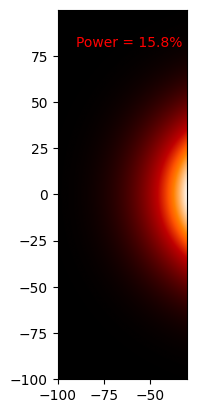

In [70]:
x_lim = -30
X,Y = np.meshgrid(x[x<x_lim],y)
I = np.exp(-2*X**2/4/w0x**2) * np.exp(-2*Y**2/4/w0y**2)
Pnew = np.trapezoid(np.trapezoid(I, axis=1), axis=0) * dx * dy
plt.imshow(I, extent=[X.min(), X.max(), Y.min(), Y.max()],cmap='gist_heat', origin='lower', aspect='equal')
plt.text(-90, 80, f'Power = {Pnew*100/Ptot:.1f}%', color = 'r')
plt.show()

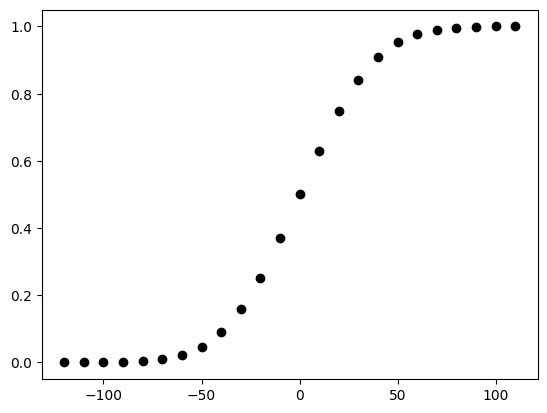

In [74]:
x_lim_arr = np.arange(-120, 120, 10)
for x_lim in x_lim_arr:
    X,Y = np.meshgrid(x[x<x_lim],y)
    I = np.exp(-2*X**2/4/w0x**2) * np.exp(-2*Y**2/4/w0y**2)
    Pnew = np.trapezoid(np.trapezoid(I, axis=1), axis=0) * dx * dy
    plt.scatter(x_lim, Pnew/Ptot, c='k')